In [7]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Au fost detectate {len(gpus)} GPU-uri active:")
    for i, gpu in enumerate(gpus):
        print(f" Placa {i}: {gpu.name}")
else:
    print("Niciun GPU detectat. Sistemul rulează lent pe CPU.")


Au fost detectate 2 GPU-uri active:
 Placa 0: /physical_device:GPU:0
 Placa 1: /physical_device:GPU:1


In [8]:

strategy = tf.distribute.MirroredStrategy()
print(f"Numărul de unități grafice sincronizate: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Numărul de unități grafice sincronizate: 2


In [3]:
# celula 1 realizeaza preprocesarea datelor + augumentare
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir= '/kaggle/input/datasets/prilia/fer2013pluscleanedaugmballanced1/train'
test_dir='/kaggle/input/datasets/prilia/fer2013pluscleanedaugmballanced1/test'

print ("Versiune TensorFlow: ", tf.__version__)
print ("Versiune Keras: ", keras.__version__)

img_size=48
batch_size=64
epoci = 50
num_classes= 7 
print ("\n partea de preprocesare si impartire a datelor")
datagen = ImageDataGenerator (
    featurewise_center=False,
    featurewise_std_normalization=False,
    rescale=1./255,
    rotation_range=10,
    zoom_range= 0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest',
    validation_split=0.20
)

test_datagen = ImageDataGenerator(rescale=1./255)

print("Setul de antrenare (80%):")
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",      
    batch_size=batch_size,
    class_mode='categorical',     
    shuffle=True                  
)

print("Setul de validare (20%):")
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,                
    subset='validation'           
)

print("Setul de testare:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Versiune TensorFlow:  2.19.0
Versiune Keras:  3.10.0

 partea de preprocesare si impartire a datelor
Setul de antrenare (80%):
Found 23251 images belonging to 7 classes.
Setul de validare (20%):
Found 4648 images belonging to 7 classes.
Setul de testare:
Found 5772 images belonging to 7 classes.


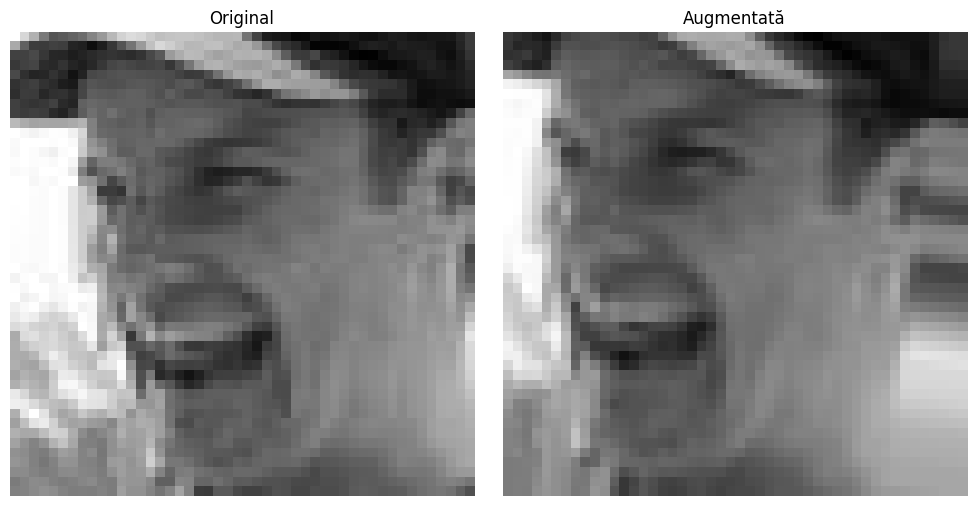

In [4]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

clase_disponibile = os.listdir(train_dir)
clasa_random = random.choice(clase_disponibile)
folder_clasa = os.path.join(train_dir, clasa_random)

imagini_disponibile = os.listdir(folder_clasa)
imagine_random = random.choice(imagini_disponibile)
cale_imagine = os.path.join(folder_clasa, imagine_random)

img = load_img(cale_imagine, target_size=(img_size, img_size), color_mode="grayscale")
img_originala = img_to_array(img)

img_augmentata = datagen.random_transform(img_originala)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title(f"Original")

plt.imshow(img_originala.reshape(img_size, img_size), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Augmentată")
plt.imshow(img_augmentata.reshape(img_size, img_size), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
train_class_labels=train_generator.class_indices
print("etichete antrenament : ",train_class_labels)

val_class_labels=val_generator.class_indices
print("etichete validare : ",val_class_labels)

test_class_labels=test_generator.class_indices
print("etichete test : ",test_class_labels)

etichete antrenament :  {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}
etichete validare :  {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}
etichete test :  {'Anger': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Neutral': 4, 'Sad': 5, 'Surprise': 6}


In [9]:
# Arhitectura EfficientNetB0 adaptata pentru GPU
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

def create_efficientnet_fer(input_shape=(48, 48, 1), num_classes=7):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    x = layers.Conv2D(3, (1, 1), padding='same', use_bias=False, name='grayscale_to_rgb')(x)

    base_model = EfficientNetB0(
        input_shape=(48, 48, 3),
        include_top=False,
        weights=None
    )
    base_model.trainable = True

    x = base_model(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

print("Construim arhitectura EfficientNetB0...")
with strategy.scope():
    model = create_efficientnet_fer(input_shape=(48, 48, 1), num_classes=num_classes)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

Construim arhitectura EfficientNetB0...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grayscale_to_rgb (Conv2D)       │ (None, 48, 48, 3)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,541 (15.48 MB)

 Trainable params: 4,016,518 (15.32 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [10]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint=ModelCheckpoint(
    "efficientnet_best_model.keras",
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=8,               
    restore_best_weights=True,
    verbose=1
)


In [11]:
import time

t_start_train = time.time()
istoric_antrenare= model.fit(
    train_generator,
    epochs=epoci,
    validation_data=val_generator,
    callbacks=[checkpoint,early_stopping]
)
t_end_train = time.time()

t_start_test = time.time()
score=model.evaluate(test_generator, verbose=0)
t_end_test = time.time()

nr_total_poze= test_generator.samples

timp_antrenament_minute = int(t_end_train - t_start_train) / 60
timp_testare_secunde = t_end_test - t_start_test
latenta_ms = 1000 * timp_testare_secunde / nr_total_poze

epoci_rulate = len(istoric_antrenare.history['loss'])

print(' RAPORT DE PERFORMANȚĂ efficientnet')

print(f'Timp total antrenament ({epoci_rulate} epoci): {timp_antrenament_minute:.2f} minute')
print(f'Numărul total de parametri: {model.count_params()}')
print(f'Acuratețea finală pe setul de test: {score[1]*100:.2f} %')
print(f'Timpul total de predicție la test: {timp_testare_secunde:.4f} secunde')
print(f'Latența pe GPU (per cadru): {latenta_ms:.4f} ms')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

E0000 00:00:1776342073.850135      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1776342085.951853     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776342087.057231     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.2109 - loss: 2.0925INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from -inf to 0.14479, saving model to efficientnet_best_model.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 174s 341ms/step - accuracy: 0.2110 - loss: 2.0922 - val_accuracy: 0.1448 - val_loss: 2.0033
Epoch 2/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2992 - loss: 1.8095
Epoch 2: val_accuracy improved from 0.14479 to 0.24785, saving model to efficientnet_best_model.keras
364/364 ━━━━━━━━━━━━━━━━━━━━ 61s 167ms/step - accuracy: 0.2992 - loss: 1.8094 - val_accuracy: 0.2478 - val_loss: 1.8856
Epoch 3/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3447 - loss: 1.6856
Epoch 3: val_accuracy imp

In [18]:
from tensorflow.keras.models import load_model
model = load_model('efficientnet_best_model.keras')

Calculăm predicțiile pe setul de test...
91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step


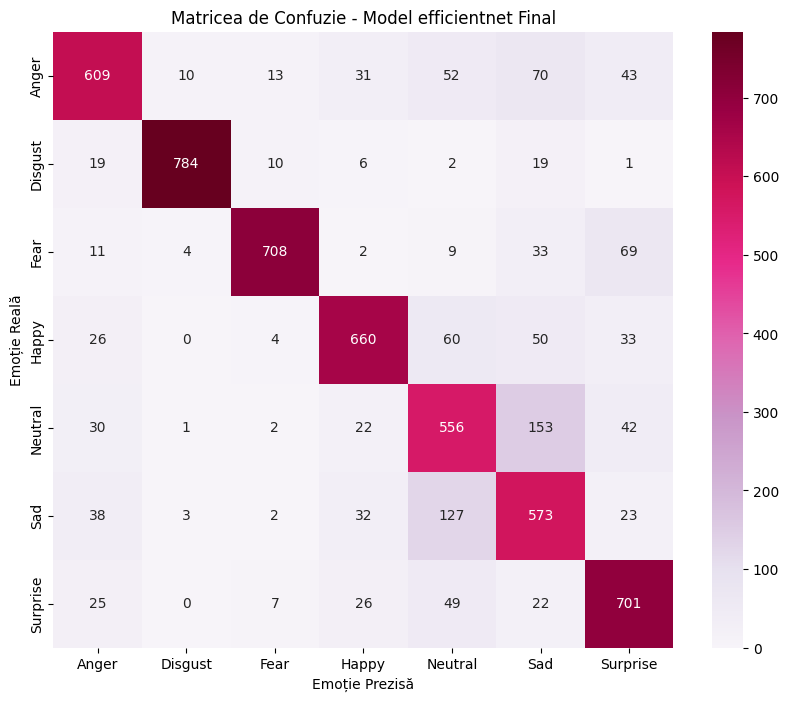


Raport de Clasificare Detaliat:

              precision    recall  f1-score   support

       Anger       0.80      0.74      0.77       828
     Disgust       0.98      0.93      0.95       841
        Fear       0.95      0.85      0.90       836
       Happy       0.85      0.79      0.82       833
     Neutral       0.65      0.69      0.67       806
         Sad       0.62      0.72      0.67       798
    Surprise       0.77      0.84      0.80       830

    accuracy                           0.80      5772
   macro avg       0.80      0.79      0.80      5772
weighted avg       0.80      0.80      0.80      5772



In [13]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

test_generator.reset()

print("Calculăm predicțiile pe setul de test...")
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

etichete = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd', 
            xticklabels=etichete, yticklabels=etichete)
plt.title('Matricea de Confuzie - Model efficientnet Final')
plt.ylabel('Emoție Reală')
plt.xlabel('Emoție Prezisă')
plt.show()

print("\nRaport de Clasificare Detaliat:\n")
print(classification_report(y_true, y_pred, target_names=etichete, zero_division=0))

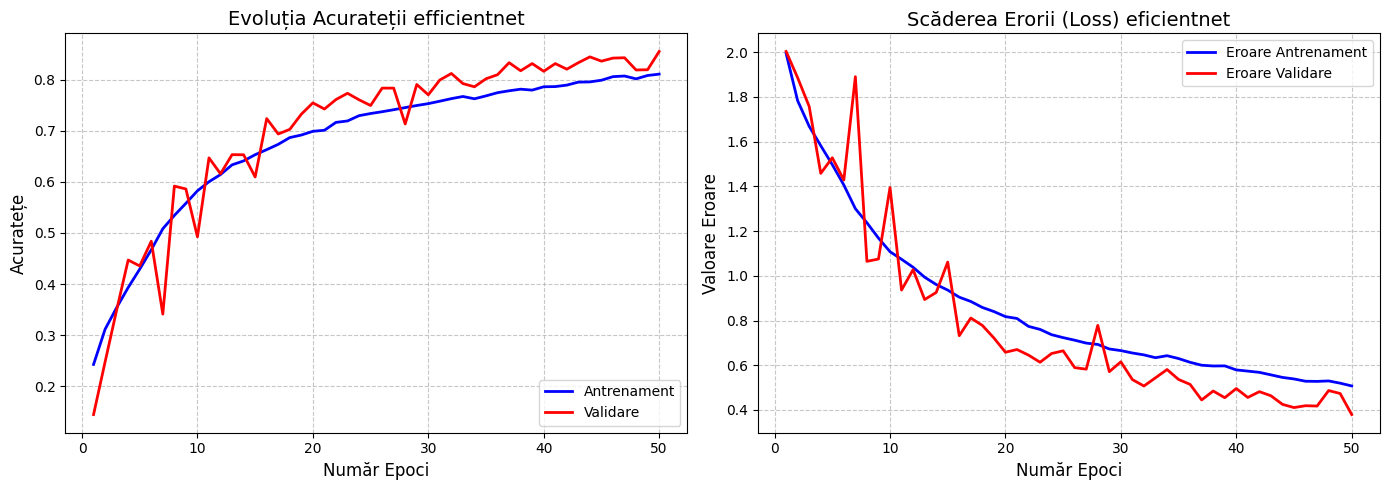

In [14]:
import matplotlib.pyplot as plt


acc = istoric_antrenare.history['accuracy']
val_acc = istoric_antrenare.history['val_accuracy']
loss = istoric_antrenare.history['loss']
val_loss = istoric_antrenare.history['val_loss']

epoci_rulate = range(1, len(acc) + 1)


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(epoci_rulate, acc, 'b-', linewidth=2, label='Antrenament')
plt.plot(epoci_rulate, val_acc, 'r-', linewidth=2, label='Validare')
plt.title('Evoluția Acurateții efficientnet', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Acuratețe', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)
plt.plot(epoci_rulate, loss, 'b-', linewidth=2, label='Eroare Antrenament')
plt.plot(epoci_rulate, val_loss, 'r-', linewidth=2, label='Eroare Validare')
plt.title('Scăderea Erorii (Loss) eficientnet', fontsize=14)
plt.xlabel('Număr Epoci', fontsize=12)
plt.ylabel('Valoare Eroare', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


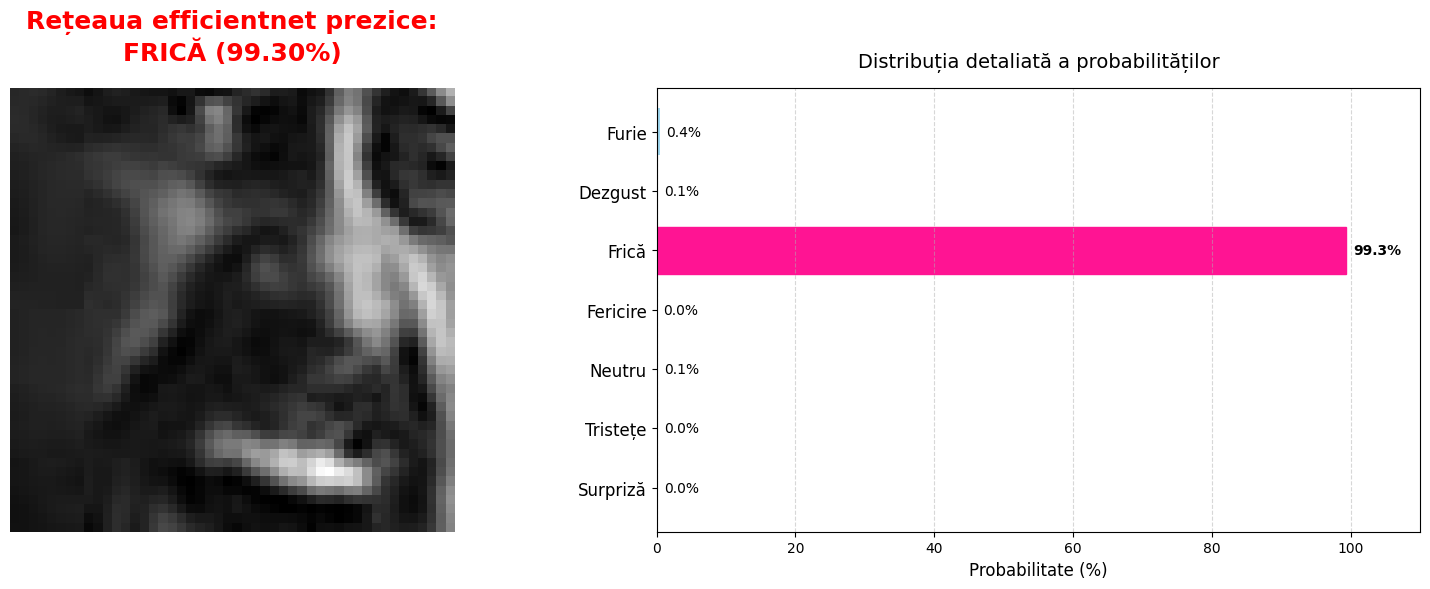

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def testeaza_cu_legenda(cale_imagine):
    
    etichete_en = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    
    clase_ro = {
        'angry': 'FURIE',
        'disgust': 'DEZGUST',
        'fear': 'FRICĂ',
        'happy': 'FERICIRE',
        'neutral': 'NEUTRU',
        'sad': 'TRISTEȚE',
        'surprise': 'SURPRIZĂ'
    }
    
    nume_ro_scurt = ['Furie', 'Dezgust', 'Frică', 'Fericire', 'Neutru', 'Tristețe', 'Surpriză']

    try:
        img_pt_model = image.load_img(cale_imagine, target_size=(48, 48), color_mode="grayscale")
    except Exception as e:
        print(f"Eroare la încărcarea imaginii: {e}")
        return

    img_array = image.img_to_array(img_pt_model)
    img_array = np.expand_dims(img_array, axis=0) 
    img_array /= 255.0 

    predictii_brute = model.predict(img_array)[0] 
    index_maxim = np.argmax(predictii_brute)
    
    emotie_w_en = etichete_en[index_maxim]
    emotie_w_ro = clase_ro[emotie_w_en]
    procent_w = predictii_brute[index_maxim] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    img_orig = cv2.imread(cale_imagine)
    if img_orig is None:
        print("Eroare: Nu am putut citi imaginea originală pentru afișare!")
        return
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    
    ax1.imshow(img_orig)
    ax1.axis('off') 
    
    culoare_titlu = 'green' if emotie_w_en == 'happy' else 'red' if emotie_w_en in ['angry', 'fear'] else 'darkblue'
    
    ax1.set_title(f"Rețeaua efficientnet prezice:\n{emotie_w_ro} ({procent_w:.2f}%)", 
                  fontsize=18, color=culoare_titlu, fontweight='bold', pad=20)

    y_pos = np.arange(len(nume_ro_scurt))
    procente_afisare = predictii_brute * 100
    
    bare = ax2.barh(y_pos, procente_afisare, align='center', color='skyblue', alpha=0.8)
    
    bare[index_maxim].set_color('deeppink')
    bare[index_maxim].set_alpha(1.0)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(nume_ro_scurt, fontsize=12)
    ax2.invert_yaxis() 
    ax2.set_xlabel('Probabilitate (%)', fontsize=12)
    ax2.set_title('Distribuția detaliată a probabilităților', fontsize=14, pad=15)
    
    for i, bar in enumerate(bare):
        latime = bar.get_width()
        ax2.text(latime + 1, bar.get_y() + bar.get_height()/2, 
                 f'{procente_afisare[i]:.1f}%', 
                 va='center', fontsize=10, fontweight='bold' if i == index_maxim else 'normal')

    ax2.set_xlim(0, 110) 
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


testeaza_cu_legenda('/kaggle/input/datasets/prilia/fer2013pluscleanedaugmballanced1/test/Fear/2_1004x1004_Training.jpg')



In [3]:
from tensorflow.keras.models import load_model

cale_model = '/kaggle/input/datasets/mindrocrobert/modelulmeu/v_cnn_best_model (1).keras'
model = load_model(cale_model)

print("✅ SUCCES: Modelul este acum încărcat în memorie!")

✅ SUCCES: Modelul este acum încărcat în memorie!
